# **SHapely Additive exPlanations**

**Imports, Data and Model loading, Preprocessing and Splitting**

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load Data
df = pd.read_csv('../data/synthetic_msme_data.csv')

# 2. Encode (must match training)
le_county = LabelEncoder()
le_sector = LabelEncoder()
df['county_encoded'] = le_county.fit_transform(df['county'])
df['sector_encoded'] = le_sector.fit_transform(df['sector'])

features = [
    'business_age_months', 'employees', 
    'monthly_revenue_kes', 'monthly_expenses_kes', 
    'total_assets_kes', 'total_liabilities_kes', 
    'loan_amount_kes', 'mpesa_volume_kes', 
    'county_encoded', 'sector_encoded'
]

X = df[features]
y = df['distress_label']

# 3. Split and Scale (Same as before)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Load the Winning Model (XGBoost)
best_model = joblib.load('../models/trained/best_model.joblib')
print("✅ Data and Best Model (XGBoost) loaded successfully.")

Matplotlib is building the font cache; this may take a moment.


✅ Data and Best Model (XGBoost) loaded successfully.


**Generating SHAP Values**

In [6]:
print("Calculating SHAP values... (This may take a minute)")

# Initialize the SHAP explainer for tree-based models
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

print("✅ SHAP values calculated successfully!")

Calculating SHAP values... (This may take a minute)
✅ SHAP values calculated successfully!


**Global Feature Importance(Summary Plot)**

Generating SHAP Summary Plot...
✅ Saved shap_feature_importance.png


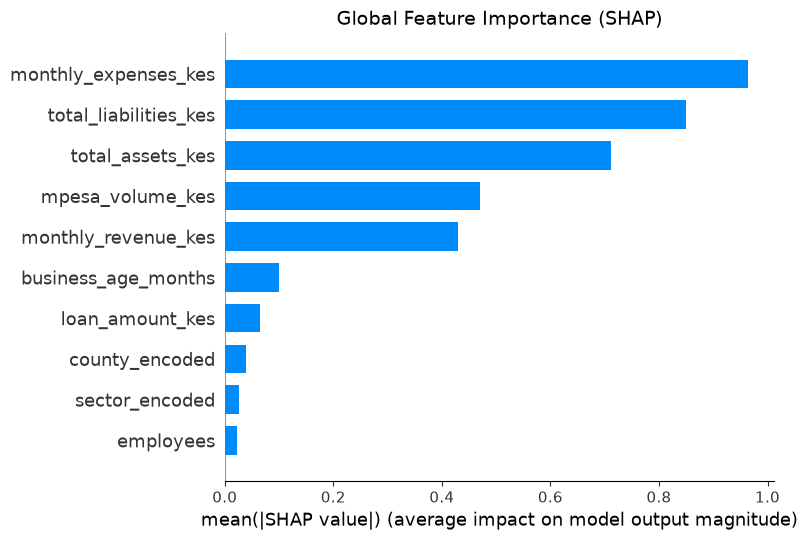

In [7]:
import matplotlib.pyplot as plt

print("Generating SHAP Summary Plot...")

# 1. Generate the plot but DO NOT show it yet (show=False)
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    feature_names=features, 
    plot_type="bar", 
    show=False
)

# 2. Add title and adjust layout
plt.title("Global Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()

# 3. SAVE the figure BEFORE calling plt.show()
plt.savefig('../models/metrics/shap_feature_importance.png', dpi=300, bbox_inches='tight')
print("✅ Saved shap_feature_importance.png")

# 4. Now display it in the notebook
plt.show()

**Explain a Single Prediction (The "Why" for the App)**

Explaining prediction for MSME at index 1 (Actual: Distressed)


✅ Saved shap_single_prediction_example.png


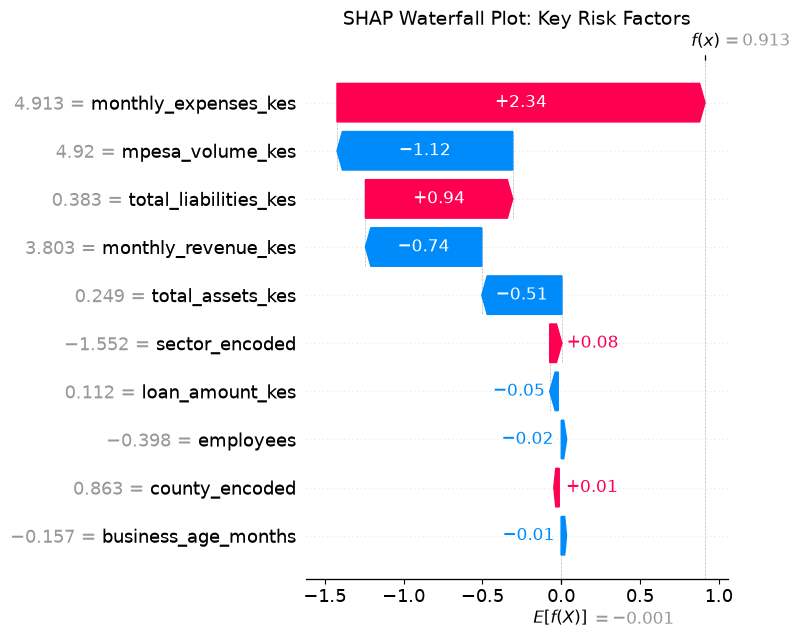

In [8]:
import matplotlib.pyplot as plt

# Find the first instance where the model predicted '1' (Distressed)
distressed_indices = np.where(y_test == 1)[0]
sample_idx = distressed_indices[0]

print(f"Explaining prediction for MSME at index {sample_idx} (Actual: Distressed)")

# Initialize JS for Jupyter display (optional, but good for interactive viewing)
shap.initjs() 

# 1. Create the explanation object
explanation = shap.Explanation(
    values=shap_values[sample_idx], 
    base_values=explainer.expected_value, 
    data=X_test_scaled[sample_idx], 
    feature_names=features
)

# 2. Generate the waterfall plot but DO NOT show it yet (show=False)
shap.waterfall_plot(explanation, show=False)
plt.title("SHAP Waterfall Plot: Key Risk Factors", fontsize=14)
plt.tight_layout()

# 3. SAVE the figure BEFORE calling plt.show()
plt.savefig('../models/metrics/shap_single_prediction_example.png', dpi=300, bbox_inches='tight')
print("✅ Saved shap_single_prediction_example.png")

# 4. Now display it in the notebook
plt.show()